In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


pd.options.display.float_format = '{:.4f}'.format

In [ ]:
#read csv
data = "loan_2014_20.csv"

df = pd.read_csv(data,low_memory=False)
df_eda = df.copy()
df_eda.head(10)


,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,earliest_cr_line,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies
0,12000.0000,36 months,7.97%,375.8800,A,A5,associate,10+ years,OWN,42000.0000,...,Jun-1996,9.0000,1.0000,11457.0000,37%,16.0000,w,Individual,0.0000,1.0000
1,32000.0000,36 months,11.99%,1062.7100,B,B5,Nurse,10+ years,MORTGAGE,155000.0000,...,Sep-2005,20.0000,0.0000,48309.0000,34.1%,42.0000,w,Individual,3.0000,0.0000
2,40000.0000,60 months,15.05%,952.6500,C,C4,Driver,9 years,MORTGAGE,120000.0000,...,Apr-2002,12.0000,0.0000,13389.0000,20.7%,26.0000,w,Individual,4.0000,0.0000
3,16000.0000,36 months,7.97%,501.1700,A,A5,Senior Investigator,5 years,RENT,79077.0000,...,Jun-2000,12.0000,0.0000,16217.0000,57.7%,20.0000,w,Individual,0.0000,0.0000
4,33000.0000,36 months,7.21%,1022.1200,A,A3,Registered Nurse,< 1 year,MORTGAGE,107000.0000,...,Dec-2005,25.0000,0.0000,18533.0000,16.1%,52.0000,w,Joint App,2.0000,0.0000
5,7000.0000,36 months,7.97%,219.2600,A,A5,CSM,10+ years,RENT,32000.0000,...,Dec-2003,13.0000,1.0000,7736.0000,22.8%,20.0000,w,Individual,0.0000,1.0000
6,10000.0000,36 months,9.44%,320.0500,B,B1,Therapist,3 years,MORTGAGE,55000.0000,...,Sep-2005,7.0000,1.0000,7188.0000,57.5%,10.0000,w,Individual,2.0000,1.0000
7,8000.0000,36 months,16.02%,281.3400,C,C5,Owner,< 1 year,MORTGAGE,120000.0000,...,Sep-1994,8.0000,0.0000,19015.0000,92.3%,34.0000,w,Joint App,6.0000,0.0000
8,12800.0000,36 months,13.59%,434.9300,C,C2,Area Director,5 years,RENT,90000.0000,...,Dec-1988,10.0000,0.0000,12660.0000,86%,23.0000,w,Individual,0.0000,0.0000
9,8000.0000,36 months,11.99%,265.6800,B,B5,pdr technician,10+ years,MORTGAGE,90000.0000,...,Jan-2005,7.0000,0.0000,5322.0000,29.9%,15.0000,w,Individual,2.0000,0.0000


In [4]:
df_eda = df.copy()

In [4]:
# Show (rows, columns)
print(df_eda.shape)

(2694776, 28)


In [5]:
print(df_eda.dtypes)

loan_amnt               float64
term                     object
int_rate                 object
installment             float64
grade                    object
sub_grade                object
emp_title                object
emp_length               object
home_ownership           object
annual_inc              float64
verification_status      object
issue_d                  object
loan_status              object
purpose                  object
title                    object
zip_code                 object
addr_state               object
dti                     float64
earliest_cr_line         object
open_acc                float64
pub_rec                 float64
revol_bal               float64
revol_util               object
total_acc               float64
initial_list_status      object
application_type         object
mort_acc                float64
pub_rec_bankruptcies    float64
dtype: object


In [6]:
# null values understanding
df_eda.isnull().sum().sort_values(ascending=False)

emp_title               249723
emp_length              196221
title                    23305
dti                       3108
revol_util                2445
zip_code                     1
mort_acc                     0
application_type             0
initial_list_status          0
total_acc                    0
revol_bal                    0
pub_rec                      0
open_acc                     0
earliest_cr_line             0
addr_state                   0
loan_amnt                    0
term                         0
purpose                      0
loan_status                  0
issue_d                      0
verification_status          0
annual_inc                   0
home_ownership               0
sub_grade                    0
grade                        0
installment                  0
int_rate                     0
pub_rec_bankruptcies         0
dtype: int64

In [7]:
# Duplicate row detection
dupes = df_eda[df_eda.duplicated(keep=False)]
dupes.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,earliest_cr_line,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies


In [8]:
# Fixing data types for summary statistics:

# changing term (object to int) 
df_eda['term'] = df_eda['term'].str.extract('(\d+)').astype(int)
df_eda['int_rate'] = df_eda['int_rate'].str.replace('%', '').astype(float) / 100
df_eda['revol_util'] = df_eda['revol_util'].str.replace('%', '').astype(float) / 100


<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
/var/folders/5c/rjsl0dxx055dbttqcd5bg_2c0000gn/T/ipykernel_26884/3257078327.py:4: SyntaxWarning: invalid escape sequence '\d'
  df_eda['term'] = df_eda['term'].str.extract('(\d+)').astype(int)


In [9]:
# Basic numerical summary
numerical_summary = df_eda.describe()

# To make it easier to read (removes scientific notation and rounds)
print(numerical_summary)

         loan_amnt         term     int_rate  installment     annual_inc  \
count 2694776.0000 2694776.0000 2694776.0000 2694776.0000   2694776.0000   
mean    15496.3144      43.2151       0.1297     455.0443     80645.7227   
std      9575.4464      11.0047       0.0489     275.3186    115315.9259   
min      1000.0000      36.0000       0.0531       7.6100         0.0000   
25%      8000.0000      36.0000       0.0917     253.8900     48000.0000   
50%     13250.0000      36.0000       0.1240     382.6200     67000.0000   
75%     20850.0000      60.0000       0.1599     609.4400     96000.0000   
max     40000.0000      60.0000       0.3099    1719.8300 110000000.0000   

               dti     open_acc      pub_rec    revol_bal   revol_util  \
count 2691668.0000 2694776.0000 2694776.0000 2694776.0000 2692331.0000   
mean       19.5464      11.7601       0.1830   17052.0794       0.4833   
std        16.2042       5.8102       0.5342   23244.8363       0.2484   
min        -1.0000 

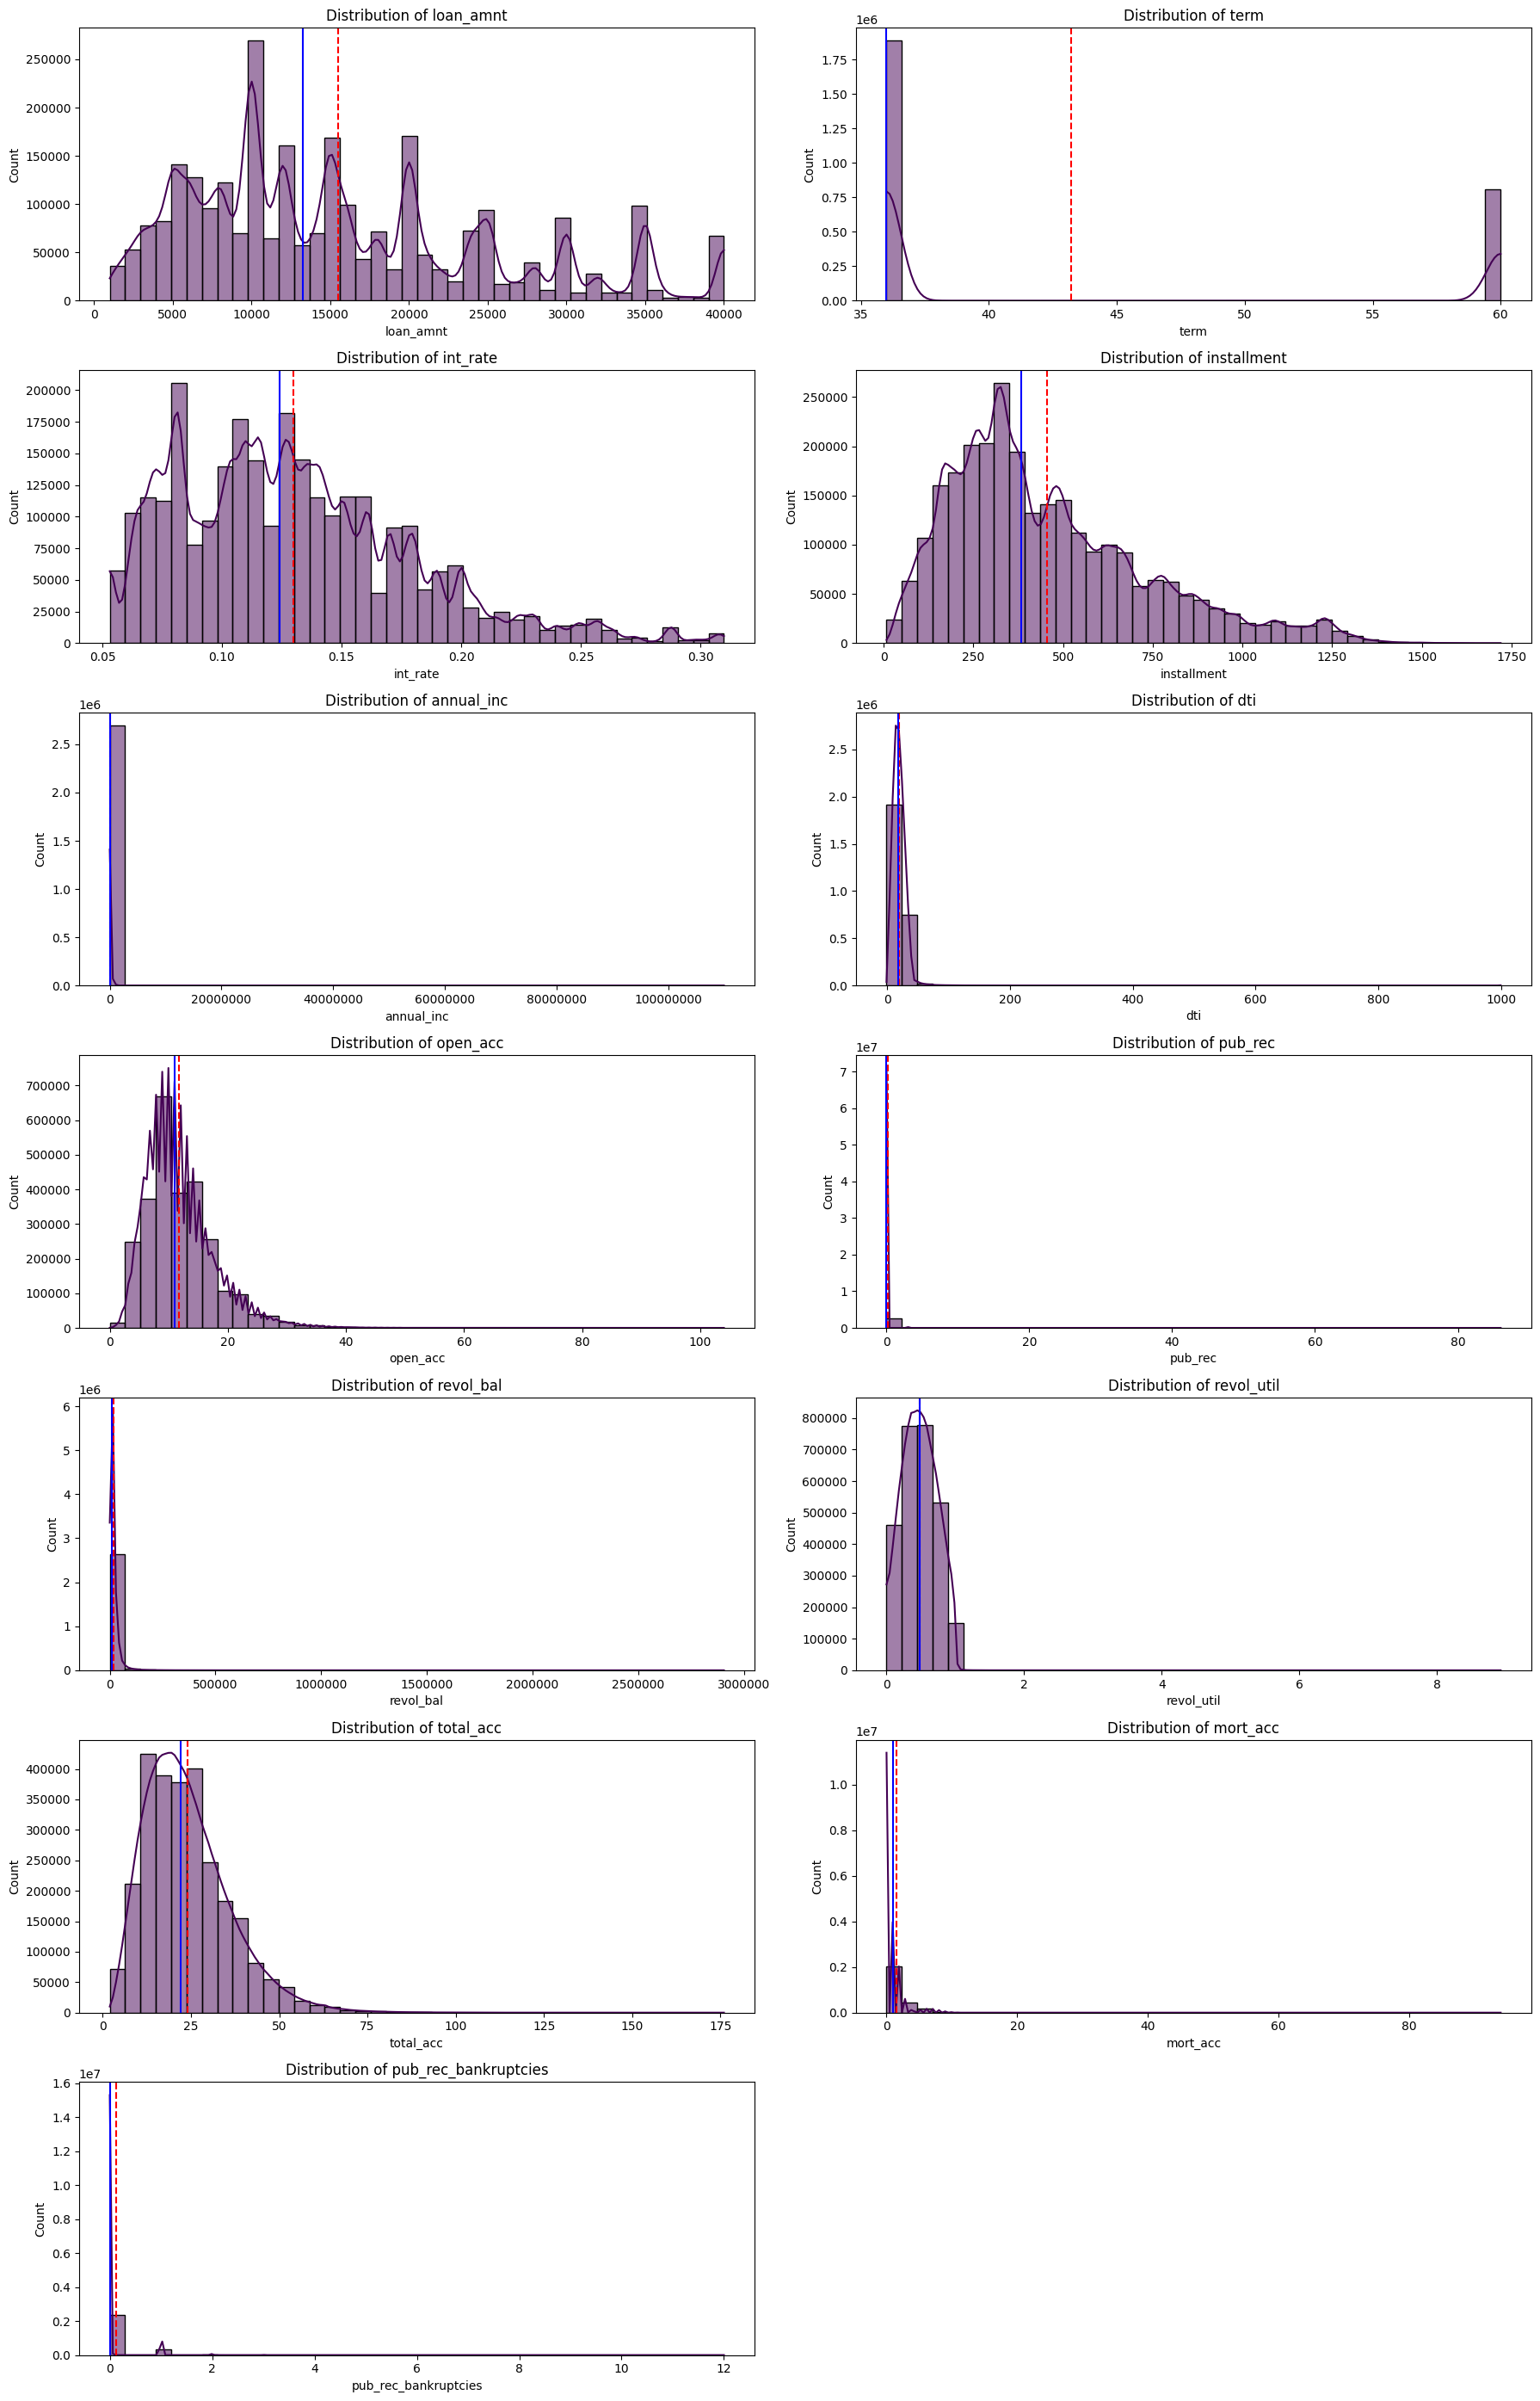

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Filter for numerical columns only
num_cols = df_eda.select_dtypes(include=['number']).columns

# 2. Setup grid
n_cols = 2
n_rows = (len(num_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

# 3. Loop through and plot Histograms
for i, col in enumerate(num_cols):
    sns.histplot(df_eda[col], bins=40, kde=True, ax=axes[i], color=plt.cm.viridis(0))
    
    # Add Mean (dashed) and Median (solid) lines
    axes[i].axvline(df_eda[col].mean(), color='red', linestyle='--', label='Mean')
    axes[i].axvline(df_eda[col].median(), color='blue', linestyle='-', label='Median')
    
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].ticklabel_format(style='plain', axis='x') # No scientific notation
    
# Cleanup
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

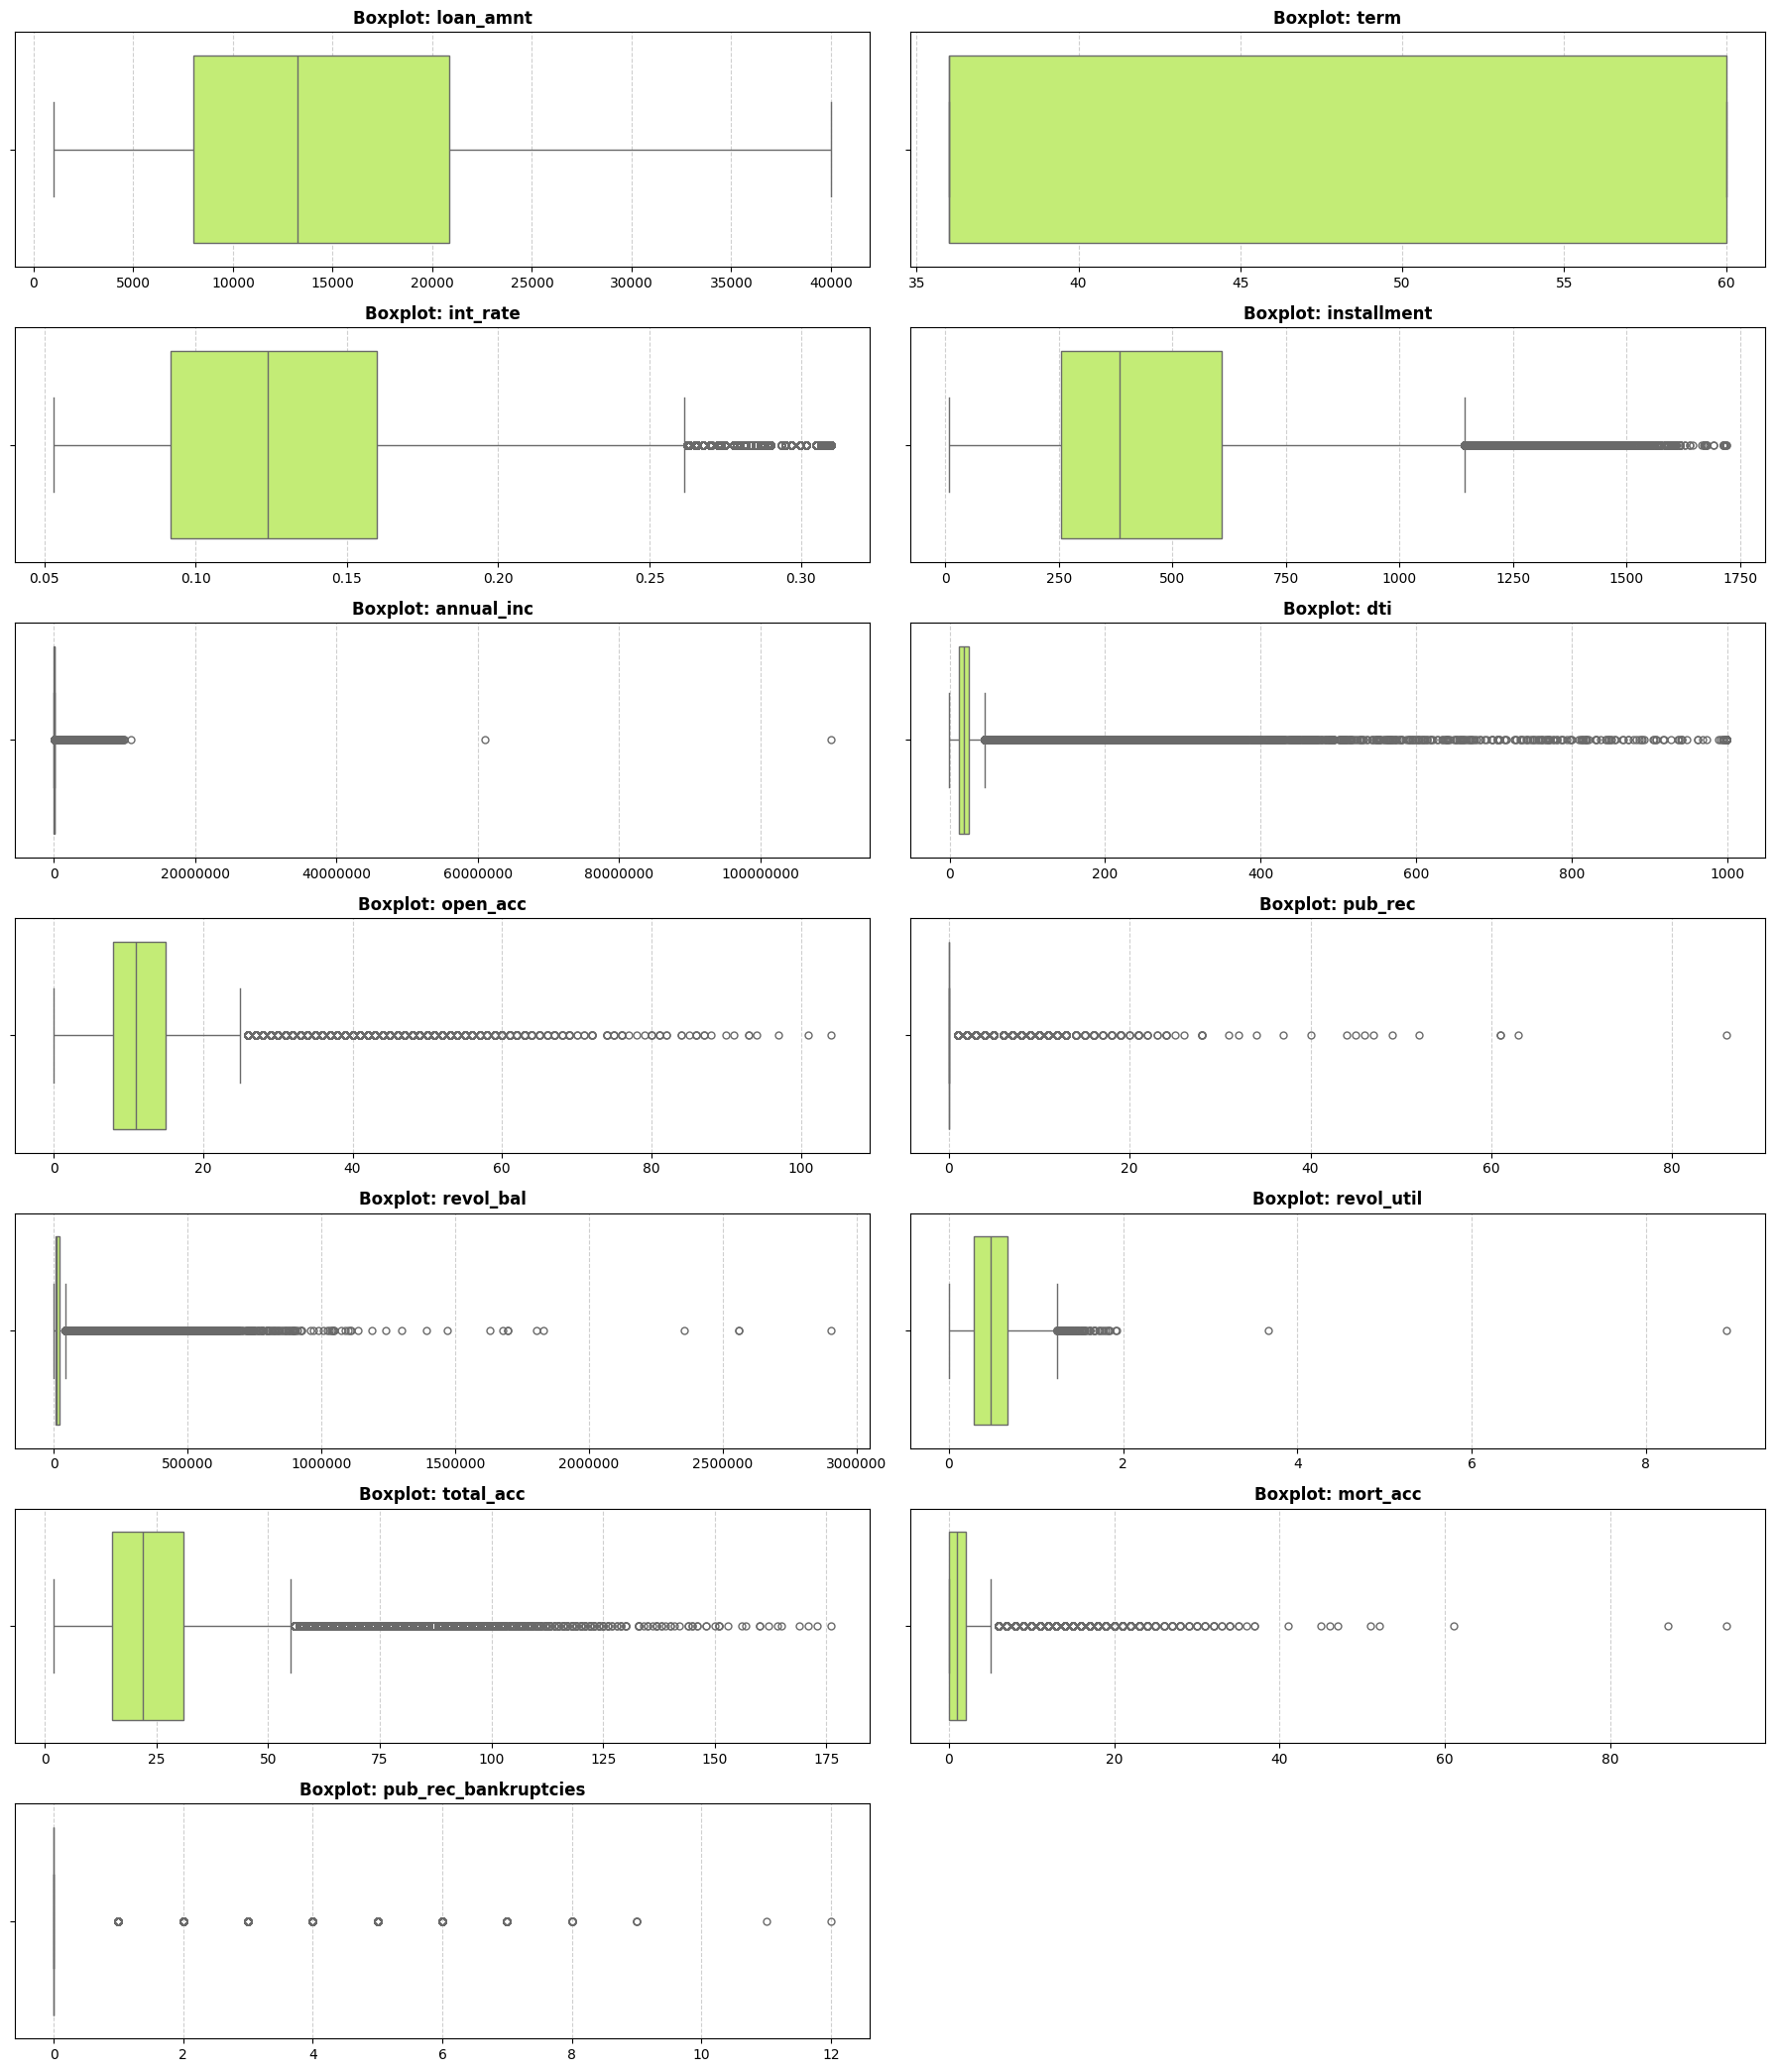

In [68]:
import math

# 1. Grab all numerical columns
num_cols = df_eda.select_dtypes(include=['number']).columns.tolist()

# 2. Setup the grid layout (3 columns is usually the sweet spot)
n_cols = 2
n_rows = math.ceil(len(num_cols) / n_cols)

# 3. Create the figure 
# Adjust the '4' to change the height of each individual row
plt.figure(figsize=(18, n_rows * 3))

for i, col in enumerate(num_cols):
    ax = plt.subplot(n_rows, n_cols, i + 1)
    
    # Create the boxplot
    # fliersize=1 makes the outlier dots smaller so they don't overlap as much
    sns.boxplot(data=df_eda, x=col, color="#C9FF63", fliersize=5)
    
    # Cleaning up the look
    ax.set_title(f'Boxplot: {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.ticklabel_format(style='plain', axis='x') # Disables scientific notation (1e6)
    
    # Add a subtle grid to help see where the median and whiskers land
    ax.xaxis.grid(True, linestyle='--', alpha=0.6)

# 4. Final layout polish
plt.tight_layout()
plt.show()

In [69]:
# Summary for text-based columns
categorical_summary = df_eda.describe(include='object')
print(categorical_summary)

          grade sub_grade emp_title emp_length home_ownership  \
count   2694776   2694776   2445053    2498555        2694776   
unique        7        35    465141         11              5   
top           B        B5   Teacher  10+ years       MORTGAGE   
freq     782561    169907     49270     875700        1321888   

       verification_status     issue_d loan_status             purpose  \
count              2694776     2694776     2694776             2694776   
unique                   3          81           8                  14   
top        Source Verified  2016-03-01  Fully Paid  debt_consolidation   
freq               1090977       61992     1305157             1506831   

                     title zip_code addr_state earliest_cr_line  \
count              2671471  2694775    2694776          2694776   
unique                2071      959         51              767   
top     Debt consolidation    750xx         CA         Aug-2006   
freq               1490017    27886

In [70]:
# Select only categorical columns
cat_cols = df_eda.select_dtypes(include=['object']).columns

# Build a custom summary
summary_data = []

for col in cat_cols:
    # Only print full value counts for columns with few unique categories
    if df_eda[col].nunique() < 15:
        print(f"\n--- {col} ---")
        print(df_eda[col].value_counts())
    else:
        print(f"\n--- {col} ---")
        print(f"High cardinality: {df_eda[col].nunique()} unique values. Top 5:")
        print(df_eda[col].value_counts().head(5))


df_cat_summary = pd.DataFrame(summary_data)

# Set display options so text doesn't get cut off
pd.set_option('display.max_colwidth', None)
print(df_cat_summary)


--- grade ---
grade
B    782561
C    743531
A    617539
D    382372
E    123398
F     34827
G     10548
Name: count, dtype: int64

--- sub_grade ---
High cardinality: 35 unique values. Top 5:
sub_grade
B5    169907
B4    168155
C1    165612
B1    151213
B2    149707
Name: count, dtype: int64

--- emp_title ---
High cardinality: 465141 unique values. Top 5:
emp_title
Teacher             49270
Manager             43065
Owner               24777
Registered Nurse    20376
Driver              19491
Name: count, dtype: int64

--- emp_length ---
emp_length
10+ years    875700
< 1 year     253881
2 years      240987
3 years      213973
1 year       179162
5 years      164641
4 years      161653
6 years      116454
7 years      102985
8 years      102168
9 years       86951
Name: count, dtype: int64

--- home_ownership ---
home_ownership
MORTGAGE    1321888
RENT        1056788
OWN          312576
ANY            3519
NONE              5
Name: count, dtype: int64

--- verification_status ---
ver

/var/folders/5c/rjsl0dxx055dbttqcd5bg_2c0000gn/T/ipykernel_81992/3989980755.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_eda, y=col, ax=ax, order=order, palette='viridis')
/var/folders/5c/rjsl0dxx055dbttqcd5bg_2c0000gn/T/ipykernel_81992/3989980755.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_eda, y=col, ax=ax, order=order, palette='viridis')
/var/folders/5c/rjsl0dxx055dbttqcd5bg_2c0000gn/T/ipykernel_81992/3989980755.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_eda, y=col, ax=ax, order=ord

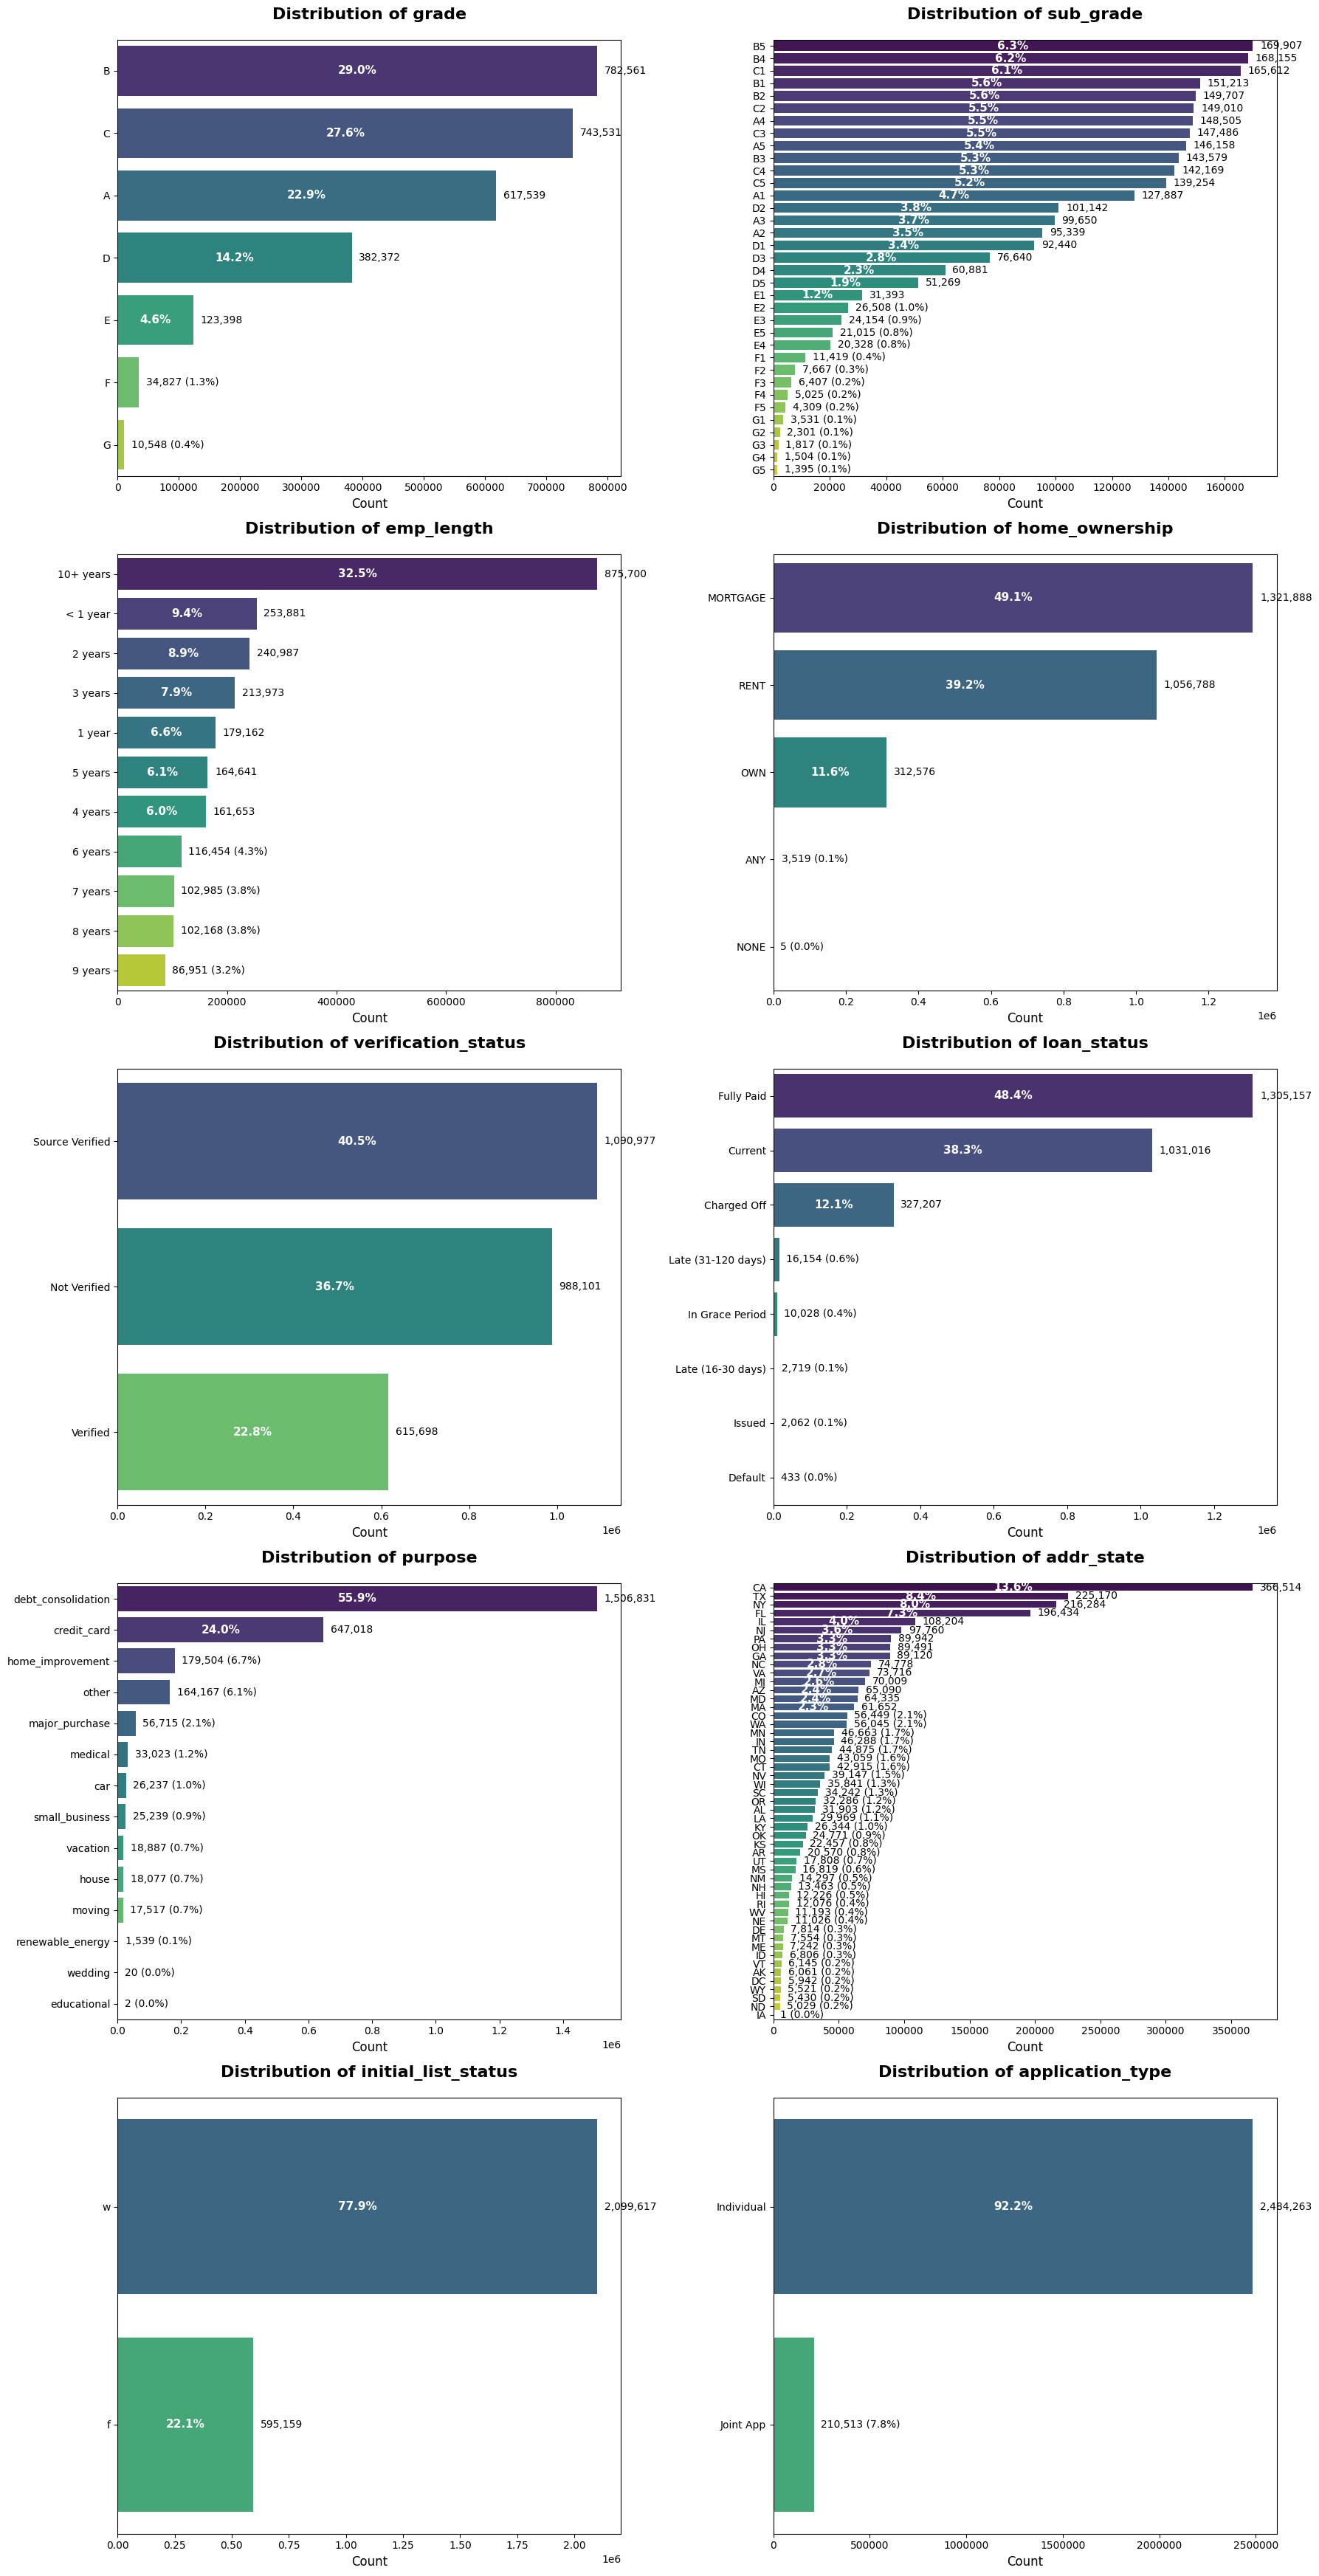

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Filter for categorical columns with manageable cardinality, excluding 'term'
low_card_cols = [col for col in df_eda.select_dtypes(include=['object']).columns 
                 if df_eda[col].nunique() < 52 and col != 'term']

# 2. Setup the grid
n_cols = 2
n_rows = (len(low_card_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 7))
axes = axes.flatten()

total_rows = len(df_eda)

# 3. Loop through and plot
for i, col in enumerate(low_card_cols):
    order = df_eda[col].value_counts().index
    ax = axes[i]
    
    # Plotting
    sns.countplot(data=df_eda, y=col, ax=ax, order=order, palette='viridis')
    ax.set_title(f'Distribution of {col}', fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Count', fontsize=12)
    ax.set_ylabel('')
    
    # Custom labeling logic for percentages and counts
    for p in ax.patches:
        width = p.get_width()
        if width < 1: continue # Handle empty bars safely
        
        # Calculate the percentage of the total dataset
        percentage_val = 100 * width / total_rows
        percentage_text = f'{percentage_val:.1f}%'
        raw_count_text = f'{int(width):,}' # Comma formatted count
        
        # Determine placement based on bar size (e.g., if bar is > 10% of x-axis width)
        # We use the current axis limits to judge "visual" width
        x_limit = ax.get_xlim()[1]
        
        if width > (x_limit * 0.15):
            # Place percentage INSIDE the bar (centered)
            ax.annotate(percentage_text, 
                        (width / 2, p.get_y() + p.get_height() / 2), 
                        ha='center', va='center', 
                        fontsize=11, color='white', fontweight='bold')
            
            # Place raw count OUTSIDE the bar
            ax.annotate(raw_count_text, 
                        (width, p.get_y() + p.get_height() / 2), 
                        xytext=(7, 0), textcoords='offset points',
                        ha='left', va='center', 
                        fontsize=10, color='black')
        else:
            # For small bars, put BOTH outside to avoid crowding
            combined_text = f'{raw_count_text} ({percentage_text})'
            ax.annotate(combined_text, 
                        (width, p.get_y() + p.get_height() / 2), 
                        xytext=(7, 0), textcoords='offset points',
                        ha='left', va='center', 
                        fontsize=10, color='black')

# 4. Cleanup: Remove unused subplots and format axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Ensure x-axis doesn't use scientific notation (e.g., 1e6)
plt.ticklabel_format(style='plain', axis='x')
plt.tight_layout()
plt.show()

In [10]:
print(df_eda.skew(numeric_only=True))

loan_amnt                0.7717
term                     0.8696
int_rate                 0.8223
installment              0.9860
annual_inc             394.7097
dti                     27.5536
open_acc                 1.3321
pub_rec                 11.0177
revol_bal               11.3156
revol_util               0.0951
total_acc                1.0672
mort_acc                 1.7908
pub_rec_bankruptcies     3.2678
dtype: float64


In [11]:
# Target Variable understanding

print(f"Dataset rows and columns: {df_eda.shape}")
status_counts = df_eda['loan_status'].value_counts().to_frame(name='Count')
status_counts['Percentage'] = (df_eda['loan_status'].value_counts(normalize=True) * 100).round(2)
status_counts.head(10)


Dataset rows and columns: (2694776, 28)


,Count,Percentage
loan_status,,
Fully Paid,1305157,48.4300
Current,1031016,38.2600
Charged Off,327207,12.1400
Late (31-120 days),16154,0.6000
In Grace Period,10028,0.3700
Late (16-30 days),2719,0.1000
Issued,2062,0.0800
Default,433,0.0200


In [12]:
# Target Variable understanding

status_counts = df_eda['home_ownership'].value_counts().to_frame(name='Count')
status_counts['Percentage'] = (df_eda['home_ownership'].value_counts(normalize=True) * 100).round(2)
status_counts.head(10)


,Count,Percentage
home_ownership,,
MORTGAGE,1321888,49.0500
RENT,1056788,39.2200
OWN,312576,11.6000
ANY,3519,0.1300
NONE,5,0.0000


/var/folders/5c/rjsl0dxx055dbttqcd5bg_2c0000gn/T/ipykernel_81992/3807063666.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_eda, x='loan_status', order=sorted_order, palette='viridis')


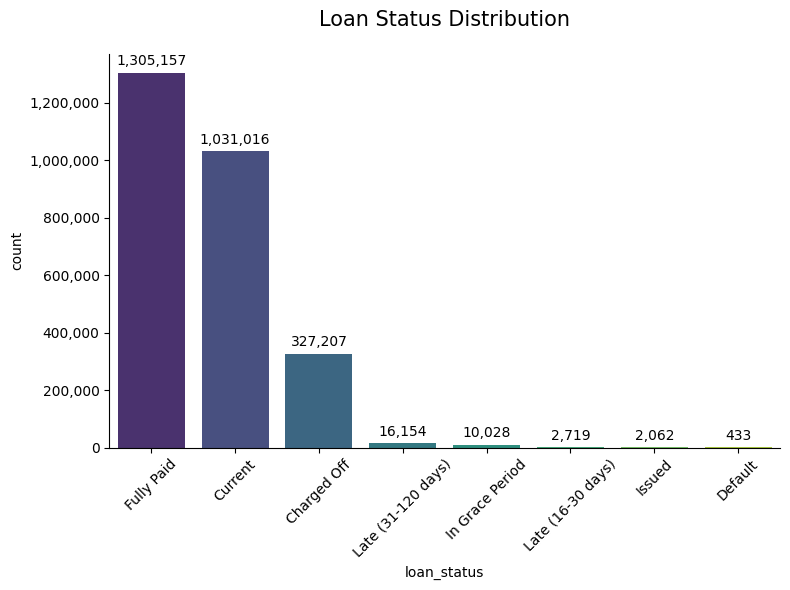

In [73]:
# 1. Setup the order
sorted_order = df_eda['loan_status'].value_counts().index

plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df_eda, x='loan_status', order=sorted_order, palette='viridis')

# 2. Loop through containers to label EVERY bar
for container in ax.containers:
    # fmt='{:,.0f}' adds commas as thousands separators
    ax.bar_label(container, padding=3, fmt='{:,.0f}', fontsize=10)

# 3. Force plain numbers on Y-axis (removes 1e6)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Styling
sns.despine() # Makes it look cleaner
plt.title('Loan Status Distribution', fontsize=15, pad=20)
plt.xticks(rotation=45)
plt.tight_layout() # Ensures labels don't get cut off

plt.show()

In [13]:
# Adjust the Target Variable to have only "Charged off" and "Fully Paid" to be certain of default or non-default cases

df_eda = df_eda[df_eda['loan_status'].isin(['Fully Paid', 'Charged Off'])]
df_eda['loan_status'] = df_eda['loan_status'].map({'Fully Paid': 0, 'Charged Off': 1})

In [14]:
# Now loan_status only has 0 (fully paid) and 1 (charged off) 
# done to ensure binary classification

print(f"Dataset rows and columns: {df_eda.shape}")
status_counts = df_eda['loan_status'].value_counts().to_frame(name='Count')
status_counts['Percentage'] = (df_eda['loan_status'].value_counts(normalize=True) * 100).round(2)
status_counts.head(10)

Dataset rows and columns: (1632364, 28)


,Count,Percentage
loan_status,,
0,1305157,79.9600
1,327207,20.0400


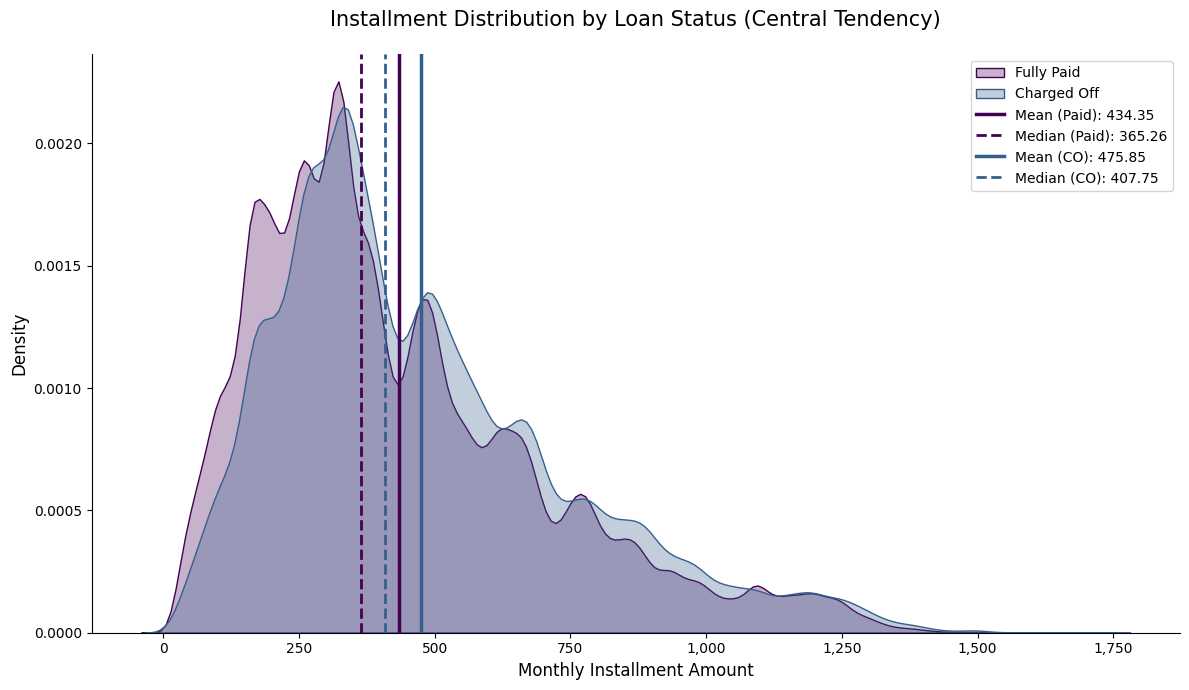

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define Viridis colors for consistency
c_paid = plt.cm.viridis(0)      # Mapping to Fully Paid
c_charged = plt.cm.viridis(0.3) # Mapping to Charged Off

# 1. Calculate Mean and Median for both groups
# (Using df_eda as your primary dataframe)
fp_data = df_eda[df_eda['loan_status'] == 0]['installment']
co_data = df_eda[df_eda['loan_status'] == 1]['installment']

fp_mean, fp_median = fp_data.mean(), fp_data.median()
co_mean, co_median = co_data.mean(), co_data.median()

# 2. Create the plot
plt.figure(figsize=(12, 7))

# KDE plots with Viridis tones
sns.kdeplot(data=fp_data, label='Fully Paid', fill=True, color=c_paid, alpha=0.3)
sns.kdeplot(data=co_data, label='Charged Off', fill=True, color=c_charged, alpha=0.3)

# 3. Add vertical lines for 'Fully Paid' (Solid Mean, Dashed Median)
plt.axvline(fp_mean, color=c_paid, linestyle='-', linewidth=2.5, 
            label=f'Mean (Paid): {fp_mean:,.2f}')
plt.axvline(fp_median, color=c_paid, linestyle='--', linewidth=2, 
            label=f'Median (Paid): {fp_median:,.2f}')

# 4. Add vertical lines for 'Charged Off'
plt.axvline(co_mean, color=c_charged, linestyle='-', linewidth=2.5, 
            label=f'Mean (CO): {co_mean:,.2f}')
plt.axvline(co_median, color=c_charged, linestyle='--', linewidth=2, 
            label=f'Median (CO): {co_median:,.2f}')

# 5. Styling and Formatting
sns.despine()
plt.title('Installment Distribution by Loan Status (Central Tendency)', fontsize=15, pad=20)
plt.xlabel('Monthly Installment Amount', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(frameon=True, facecolor='white', framealpha=0.8)

# Optional: Add a thousand separator to the x-axis for readability
import matplotlib.ticker as ticker
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

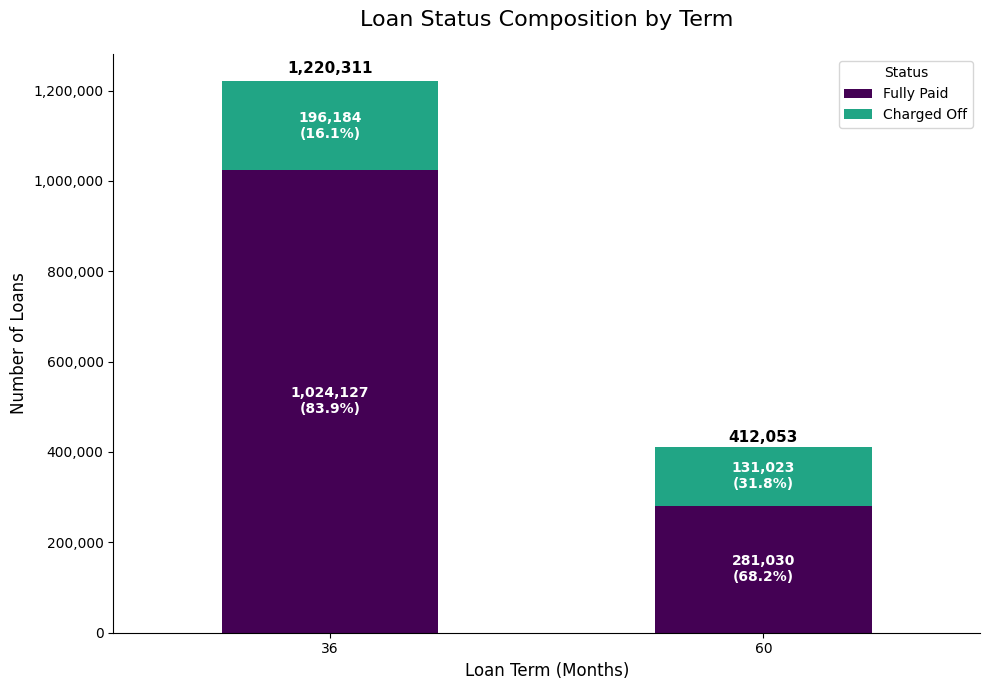

In [77]:
import matplotlib.ticker as ticker
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare the data
stack_data = df_eda.groupby(['term', 'loan_status']).size().unstack(fill_value=0)

# 2. Setup the order and calculate percentages
stack_data['total'] = stack_data.sum(axis=1)
stack_data = stack_data.sort_values('total', ascending=False)
stack_data['pct_0'] = (stack_data[0] / stack_data['total'] * 100).round(1)
stack_data['pct_1'] = (stack_data[1] / stack_data['total'] * 100).round(1)

# 3. Create the plot using Viridis
# We pick index 0 and 150 for high contrast within the Viridis palette
viridis_colors = [plt.cm.viridis(0), plt.cm.viridis(150)] 

ax = stack_data[[0, 1]].plot(kind='bar', stacked=True, figsize=(10, 7), color=viridis_colors)

# 4. Custom Labeling (Counts + Percentages)
for i, (idx, row) in enumerate(stack_data.iterrows()):
    # Label for Fully Paid (0) - Lower segment
    ax.text(i, row[0]/2, f"{row[0]:,.0f}\n({row['pct_0']}%)", 
            ha='center', va='center', color='white', fontweight='bold', fontsize=10)
    
    # Label for Charged Off (1) - Upper segment
    # Position: base of segment (row[0]) + middle of its own height (row[1]/2)
    ax.text(i, row[0] + (row[1]/2), f"{row[1]:,.0f}\n({row['pct_1']}%)", 
            ha='center', va='center', color='white', fontweight='bold', fontsize=10)

# 5. Total counts on top
for i, total in enumerate(stack_data['total']):
    ax.text(i, total + (total * 0.01), f'{total:,.0f}', 
            ha='center', va='bottom', fontweight='bold', fontsize=11)

# 6. Final Formatting
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
sns.despine()
plt.title('Loan Status Composition by Term', fontsize=16, pad=20)
plt.xlabel('Loan Term (Months)', fontsize=12)
plt.ylabel('Number of Loans', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Status', labels=['Fully Paid', 'Charged Off'], loc='upper right')
plt.tight_layout()

plt.show()

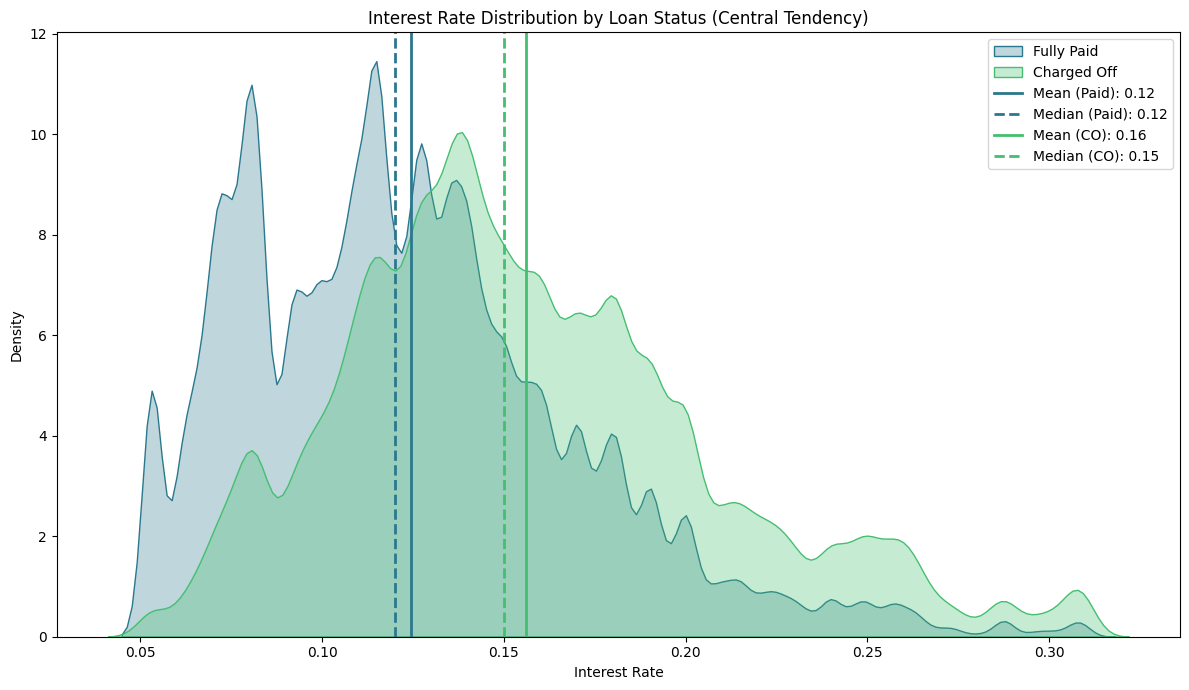

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate Mean and Median for both groups
fp_mean = df_eda[df_eda['loan_status'] == 0]['int_rate'].mean()
fp_median = df_eda[df_eda['loan_status'] == 0]['int_rate'].median()

co_mean = df_eda[df_eda['loan_status'] == 1]['int_rate'].mean()
co_median = df_eda[df_eda['loan_status'] == 1]['int_rate'].median()

# 2. Create the plot
plt.figure(figsize=(12, 7))

# Original KDE plots
sns.kdeplot(data=df_eda[df_eda['loan_status'] == 0], 
            x='int_rate', label='Fully Paid', fill=True, color=plt.cm.viridis(0.4), alpha=0.3)
sns.kdeplot(data=df_eda[df_eda['loan_status'] == 1], 
            x='int_rate', label='Charged Off', fill=True, color=plt.cm.viridis(0.7), alpha=0.3)

# 3. Add vertical lines for 'Fully Paid' (using darker green for contrast)
plt.axvline(fp_mean, color=plt.cm.viridis(0.4), linestyle='-', linewidth=2, 
            label=f'Mean (Paid): {fp_mean:.2f}')
plt.axvline(fp_median, color=plt.cm.viridis(0.4), linestyle='--', linewidth=2, 
            label=f'Median (Paid): {fp_median:.2f}')

# 4. Add vertical lines for 'Charged Off' (using a darker purple)
plt.axvline(co_mean, color=plt.cm.viridis(0.7), linestyle='-', linewidth=2, 
            label=f'Mean (CO): {co_mean:.2f}')
plt.axvline(co_median, color=plt.cm.viridis(0.7), linestyle='--', linewidth=2, 
            label=f'Median (CO): {co_median:.2f}')

plt.title('Interest Rate Distribution by Loan Status (Central Tendency)')
plt.xlabel('Interest Rate')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

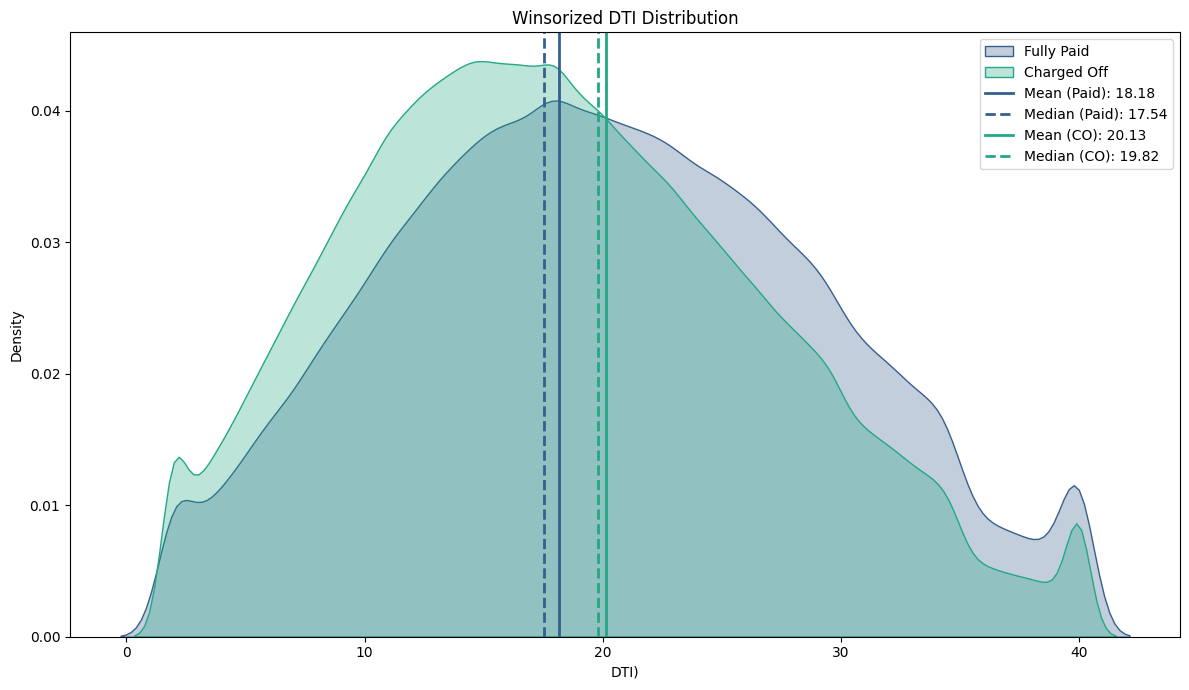

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

c1 = plt.cm.viridis(0.3)
c2 = plt.cm.viridis(0.6)

# DTI preprocessing (winsorization)
# replacing -1 to 0 values and 999 values with NaN
df_eda.loc[df_eda['dti'] <= 0, 'dti'] = np.nan
# impute with median
dti_median = df_eda['dti'].median()
df_eda['dti'] = df_eda['dti'].fillna(dti_median)
# Apply winsorization for values beyond 99th percentile
upper_limit = df_eda['dti'].quantile(0.99)
lower_limit = df_eda['dti'].quantile(0.01)
df_eda['dti_winsorized'] = df_eda['dti'].clip(lower=lower_limit, upper=upper_limit)

fp_valid_logs = df_eda[(df_eda['loan_status'] == 0)]['dti_winsorized']
co_valid_logs = df_eda[(df_eda['loan_status'] == 1)]['dti_winsorized']

# 3. Calculate Mean and Median for the LOG-transformed data
fp_mean = fp_valid_logs.mean()
fp_median = fp_valid_logs.median()

co_mean = co_valid_logs.mean()
co_median = co_valid_logs.median()

# 4. Create the plot
plt.figure(figsize=(12, 7))

# KDE plots
sns.kdeplot(data=df_eda[df_eda['loan_status'] == 1], 
            x='dti_winsorized', label='Fully Paid', fill=True, color=c1, alpha=0.3)
sns.kdeplot(data=df_eda[df_eda['loan_status'] == 0], 
            x='dti_winsorized', label='Charged Off', fill=True, color=c2, alpha=0.3)

# 5. Add vertical lines for 'Fully Paid'
plt.axvline(fp_mean, color=c1, linestyle='-', linewidth=2, label=f'Mean (Paid): {fp_mean:.2f}')
plt.axvline(fp_median, color=c1, linestyle='--', linewidth=2, label=f'Median (Paid): {fp_median:.2f}')
# 6. Add vertical lines for 'Charged Off'

plt.axvline(co_mean, color=c2, linestyle='-', linewidth=2, label=f'Mean (CO): {co_mean:.2f}')
plt.axvline(co_median, color=c2, linestyle='--', linewidth=2, label=f'Median (CO): {co_median:.2f}')

plt.title('Winsorized DTI Distribution')
plt.xlabel('DTI)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

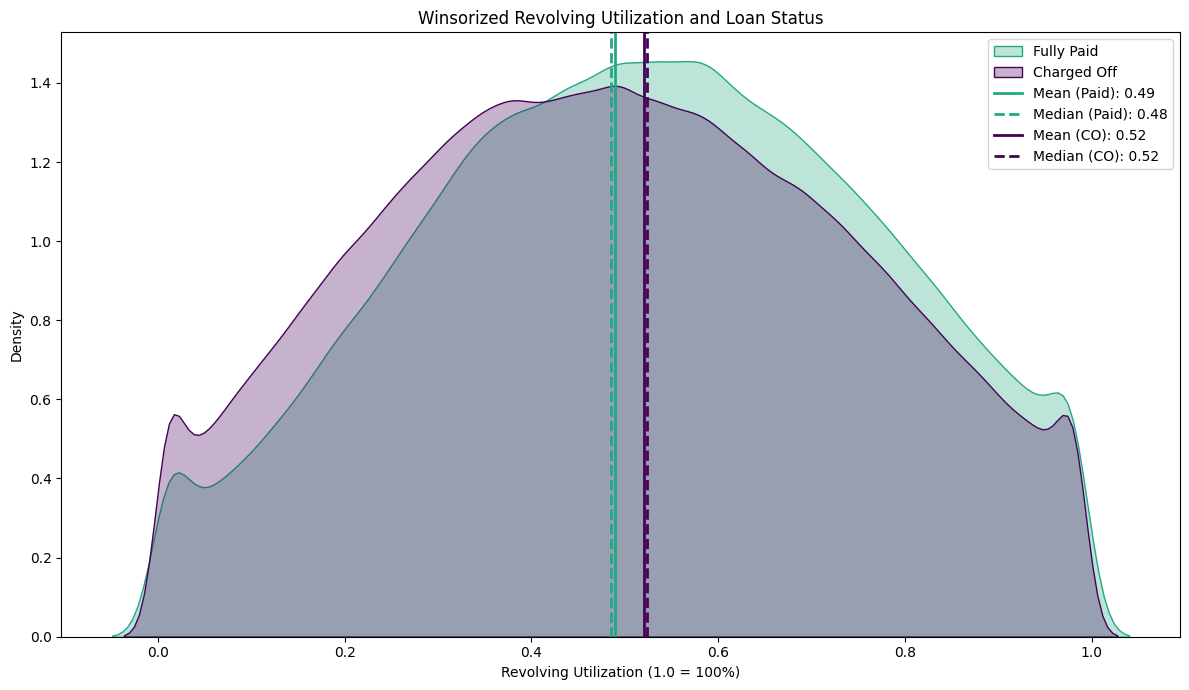

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

# Revolving Utilization (revol_util)
# impute with median
revol_median = df_eda['revol_util'].median()
df_eda['revol_util'] = df_eda['revol_util'].fillna(revol_median)
# Apply winsorization for values beyond 99th percentile
upper_limit = df_eda['revol_util'].quantile(0.99)
lower_limit = df_eda['revol_util'].quantile(0.01)
df_eda['revol_util_winsorized'] = df_eda['revol_util'].clip(lower=lower_limit, upper=upper_limit)

c1 = plt.cm.viridis(0.6) # Blue for Fully Paid
c2 =plt.cm.viridis(1) # Red for Charged Off

# 2. Calculate Stats for the capped data
fp_mean = df_eda[df_eda['loan_status'] == 0]['revol_util_winsorized'].mean()
fp_median = df_eda[df_eda['loan_status'] == 0]['revol_util_winsorized'].median()

co_mean = df_eda[df_eda['loan_status'] == 1]['revol_util_winsorized'].mean()
co_median = df_eda[df_eda['loan_status'] == 1]['revol_util_winsorized'].median()

# 3. Create the plot
plt.figure(figsize=(12, 7))

# KDE Plots
sns.kdeplot(data=df_eda[df_eda['loan_status'] == 1], 
            x='revol_util_winsorized', label='Fully Paid', fill=True, color=c1, alpha=0.3)
sns.kdeplot(data=df_eda[df_eda['loan_status'] == 0], 
            x='revol_util_winsorized', label='Charged Off', fill=True, color=c2, alpha=0.3)

# 4. Add vertical lines for 'Fully Paid'
plt.axvline(fp_mean, color=c1, linestyle='-', linewidth=2, 
            label=f'Mean (Paid): {fp_mean:.2f}')
plt.axvline(fp_median, color=c1, linestyle='--', linewidth=2, 
            label=f'Median (Paid): {fp_median:.2f}')

# 5. Add vertical lines for 'Charged Off'
plt.axvline(co_mean, color=c2, linestyle='-', linewidth=2, 
            label=f'Mean (CO): {co_mean:.2f}')
plt.axvline(co_median, color=c2, linestyle='--', linewidth=2, 
            label=f'Median (CO): {co_median:.2f}')

plt.title('Winsorized Revolving Utilization and Loan Status')
plt.xlabel('Revolving Utilization (1.0 = 100%)')
plt.ylabel('Density')
plt.legend(loc='upper right') # Moving legend to prevent overlap with the curves
plt.tight_layout()
plt.show()

# Preprocessing

In [3]:
# Data preprocessing steps:
# 1. data type changing

df_eda = df.copy()

# changing term (object to int) 
df_eda['term'] = df_eda['term'].str.extract('(\d+)').astype(int)
df_eda['int_rate'] = df_eda['int_rate'].str.replace('%', '').astype(float) / 100
df_eda['revol_util'] = df_eda['revol_util'].str.replace('%', '').astype(float) / 100


print(df_eda.dtypes)


<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
/var/folders/5c/rjsl0dxx055dbttqcd5bg_2c0000gn/T/ipykernel_6248/2923036562.py:7: SyntaxWarning: invalid escape sequence '\d'
  df_eda['term'] = df_eda['term'].str.extract('(\d+)').astype(int)


loan_amnt               float64
term                      int64
int_rate                float64
installment             float64
grade                    object
sub_grade                object
emp_title                object
emp_length               object
home_ownership           object
annual_inc              float64
verification_status      object
issue_d                  object
loan_status              object
purpose                  object
title                    object
zip_code                 object
addr_state               object
dti                     float64
earliest_cr_line         object
open_acc                float64
pub_rec                 float64
revol_bal               float64
revol_util              float64
total_acc               float64
initial_list_status      object
application_type         object
mort_acc                float64
pub_rec_bankruptcies    float64
dtype: object


In [4]:
# data cleaning

# Debt to Income Ratio (DTI)
# replacing -1 to 0 values and 999 values with NaN
df_eda.loc[df_eda['dti'] <= 0, 'dti'] = np.nan



In [5]:
# data imputation

# Debt to Income Ratio (DTI)
# impute with median
dti_median = df_eda['dti'].median()
df_eda['dti'] = df_eda['dti'].fillna(dti_median)


# Revolving Utilization (revol_util)
# impute with median
revol_median = df_eda['revol_util'].median()
df_eda['revol_util'] = df_eda['revol_util'].fillna(revol_median)


In [6]:
# outlier handling

# Debt to Income Ratio (DTI)
# Apply winsorization for values beyond 99th percentile
upper_limit = df_eda['dti'].quantile(0.99)
lower_limit = df_eda['dti'].quantile(0.01)
df_eda['dti_winsorized'] = df_eda['dti'].clip(lower=lower_limit, upper=upper_limit)

# Revolving Utilization (revol_util)
# Apply winsorization for values beyond 99th percentile
upper_limit = df_eda['revol_util'].quantile(0.99)
df_eda['revol_util_winsorized'] = df_eda['revol_util'].clip(upper=upper_limit)

# Revolving Balance (revol_bal)
# Apply winsorization for values beyond 99th percentile
upper_limit = df_eda['revol_bal'].quantile(0.99)
df_eda['revol_bal_winsorized'] = df_eda['revol_bal'].clip(upper=upper_limit)

# Open Account (open_acc)
# Apply winsorization for values beyond 99th percentile
upper_limit = df_eda['open_acc'].quantile(0.99)
df_eda['open_acc_winsorized'] = df_eda['open_acc'].clip(upper=upper_limit)

# Total Account (total_acc)
# Apply winsorization for values beyond 99th percentile
upper_limit = df_eda['total_acc'].quantile(0.99)
df_eda['total_acc_winsorized'] = df_eda['total_acc'].clip(upper=upper_limit)

# Mortgage Accounts (mort_acc)
# Apply winsorization for values beyond 99th percentile
upper_limit = df_eda['mort_acc'].quantile(0.99)
df_eda['mort_acc_winsorized'] = df_eda['mort_acc'].clip(upper=upper_limit)

# Annual Income (annual_inc)
# Apply log transformation to handle extreme data points
df_eda['log_annual_inc'] = np.log1p(df_eda['annual_inc'])

In [7]:
# data standardization

# Adjust the Target Variable to have only "Charged off" and "Fully Paid" to be certain of default or non-default cases
df_eda = df_eda[df_eda['loan_status'].isin(['Fully Paid', 'Charged Off'])]
df_eda['loan_status'] = df_eda['loan_status'].map({'Fully Paid': 0, 'Charged Off': 1}).astype(int)

# Categorizing 'ANY' or 'OTHER' home_ownership classes as RENT, justification: rent has highest risk in default loan_status
df_eda['home_ownership'] = df_eda['home_ownership'].replace(['ANY', 'NONE'], 'RENT')


In [8]:
# Feature engineering

# 1. Create the feature: 1 if either condition is met, else 0
df_eda['has_pub_rec'] = ((df_eda['pub_rec'] > 1) | (df_eda['pub_rec_bankruptcies'] > 1)).astype(int)
print(df_eda['has_pub_rec'].value_counts())


# 2. Convert Sub-Grade to Numerical (1 to 35) 
# Create the mapping: A1=1, A2=2... G5=35
grades = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
sub_grades = [f"{g}{i}" for g in grades for i in range(1, 6)]
sub_grade_mapping = {val: i+1 for i, val in enumerate(sub_grades)}
df_eda['sub_grade_num'] = df_eda['sub_grade'].map(sub_grade_mapping)


# 3. Calculate Credit Age in Months relative to the earliest_cr_line
df_eda['earliest_cr_line'] = pd.to_datetime(df_eda['earliest_cr_line'])
# Since your data ends around 2020, we'll use Dec 2020 as the "present"
reference_date = pd.to_datetime('2020-12-01')
df_eda['credit_age_months'] = (
    (reference_date.year - df_eda['earliest_cr_line'].dt.year) * 12 +
    (reference_date.month - df_eda['earliest_cr_line'].dt.month)
)



has_pub_rec
0    1586680
1      45684
Name: count, dtype: int64


/var/folders/5c/rjsl0dxx055dbttqcd5bg_2c0000gn/T/ipykernel_6248/3835578295.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_eda['earliest_cr_line'] = pd.to_datetime(df_eda['earliest_cr_line'])


In [11]:
risk_summary = df_eda.groupby('home_ownership')['loan_status'].value_counts(normalize=True).unstack()[1]
print(risk_summary,"\n")


home_ownership
MORTGAGE   0.1721
OWN        0.2053
RENT       0.2345
Name: 1, dtype: float64 



In [12]:
# Printing the raw count and the percentage for Application Type
counts = df['application_type'].value_counts()
percentages = df['application_type'].value_counts(normalize=True) * 100
print(pd.concat([counts, percentages], axis=1, keys=['Count', 'Percentage (%)']), "\n")

# Check the distribution and default rate
status_risk = df_eda.groupby('application_type')['loan_status'].value_counts(normalize=True).unstack()[1]
print(status_risk,"\n")

# The Verdict: Because 'Joint' applications are so rare, the model doesn't have enough samples to learn a
# reliable pattern. Furthermore, the risk difference between the two is usually negligible.


list_risk = df_eda.groupby('initial_list_status')['loan_status'].value_counts(normalize=True).unstack()[1]
print(list_risk, "\n")
# The two classes have identical risk of default, showing that it is better to just drop these columns

# 1. Filter out missing values from emp_length (7% missing values)
df_clean = df_eda.dropna(subset=['emp_length']).copy()
df_clean['is_default'] = (df_clean['loan_status'] == 1).astype(int)
risk_percentage = df_clean.groupby('emp_length')['is_default'].mean() * 100
risk_percentage = risk_percentage.sort_values(ascending=False).round(2)
print("Percentage of Default by Employment Length:")
print(risk_percentage.astype(str) + '%')
print(f"Missing Data: {df_eda['emp_length'].isna().mean():.2%}")
print(f"Risk Variance: {df_eda.groupby('emp_length')['loan_status'].mean().var():.8f}")
# emp lenght has 7% missing values, and imputation methods may introduce artifical noise, thereby lowering 
# the quality of the model prediction.



                    Count  Percentage (%)
application_type                         
Individual        2484263         92.1881
Joint App          210513          7.8119 

application_type
Individual   0.1984
Joint App    0.2462
Name: 1, dtype: float64 

initial_list_status
f   0.2042
w   0.1989
Name: 1, dtype: float64 

Percentage of Default by Employment Length:
emp_length
< 1 year     21.28%
1 year        20.8%
4 years      20.17%
3 years      20.17%
5 years      20.08%
2 years      19.86%
8 years       19.8%
7 years      19.59%
6 years      19.42%
9 years      19.32%
10+ years    18.48%
Name: is_default, dtype: object
Missing Data: 6.63%
Risk Variance: 0.00005588


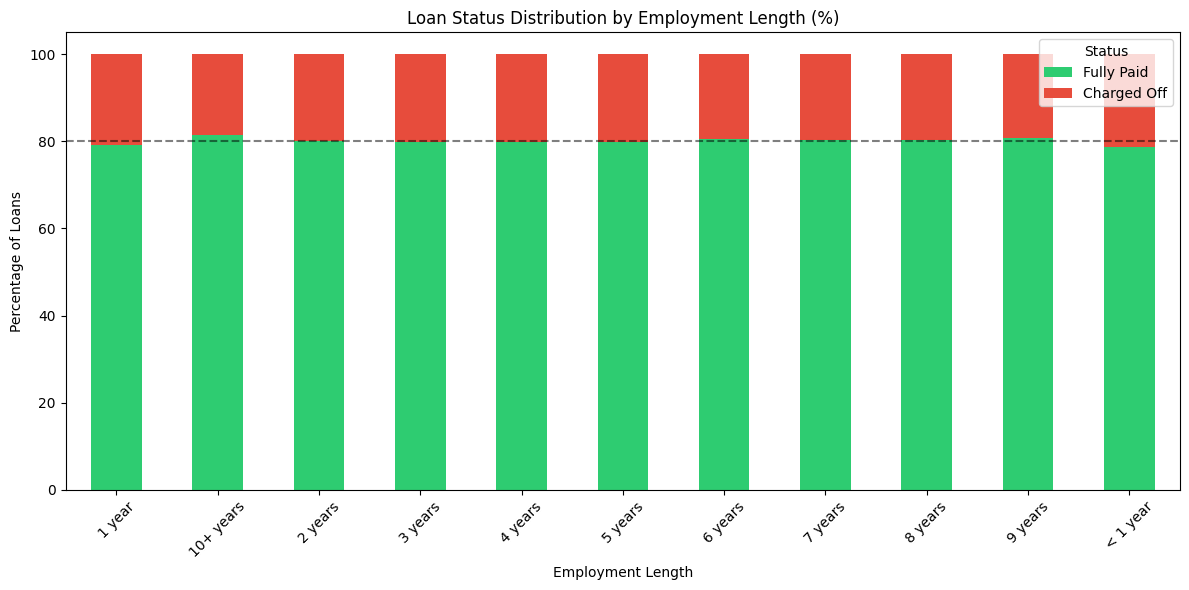

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Create a cross-tabulation of counts
# 0 = Fully Paid, 1 = Charged Off
plot_data = pd.crosstab(df_eda['emp_length'], df_eda['loan_status'])

# 2. Normalize to show percentages (the "Stacked 100%" view)
plot_data_pct = plot_data.div(plot_data.sum(1), axis=0) * 100

# 3. Plot
ax = plot_data_pct.plot(kind='bar', stacked=True, figsize=(12, 6), color=['#2ecc71', '#e74c3c'])

plt.title('Loan Status Distribution by Employment Length (%)')
plt.xlabel('Employment Length')
plt.ylabel('Percentage of Loans')
plt.legend(title='Status', labels=['Fully Paid', 'Charged Off'], loc='upper right')
plt.xticks(rotation=45)

# Add a horizontal line showing the average default rate to highlight the lack of variance
plt.axhline(y=80, color='black', linestyle='--', alpha=0.5) 

plt.tight_layout()
plt.show()

<Axes: >

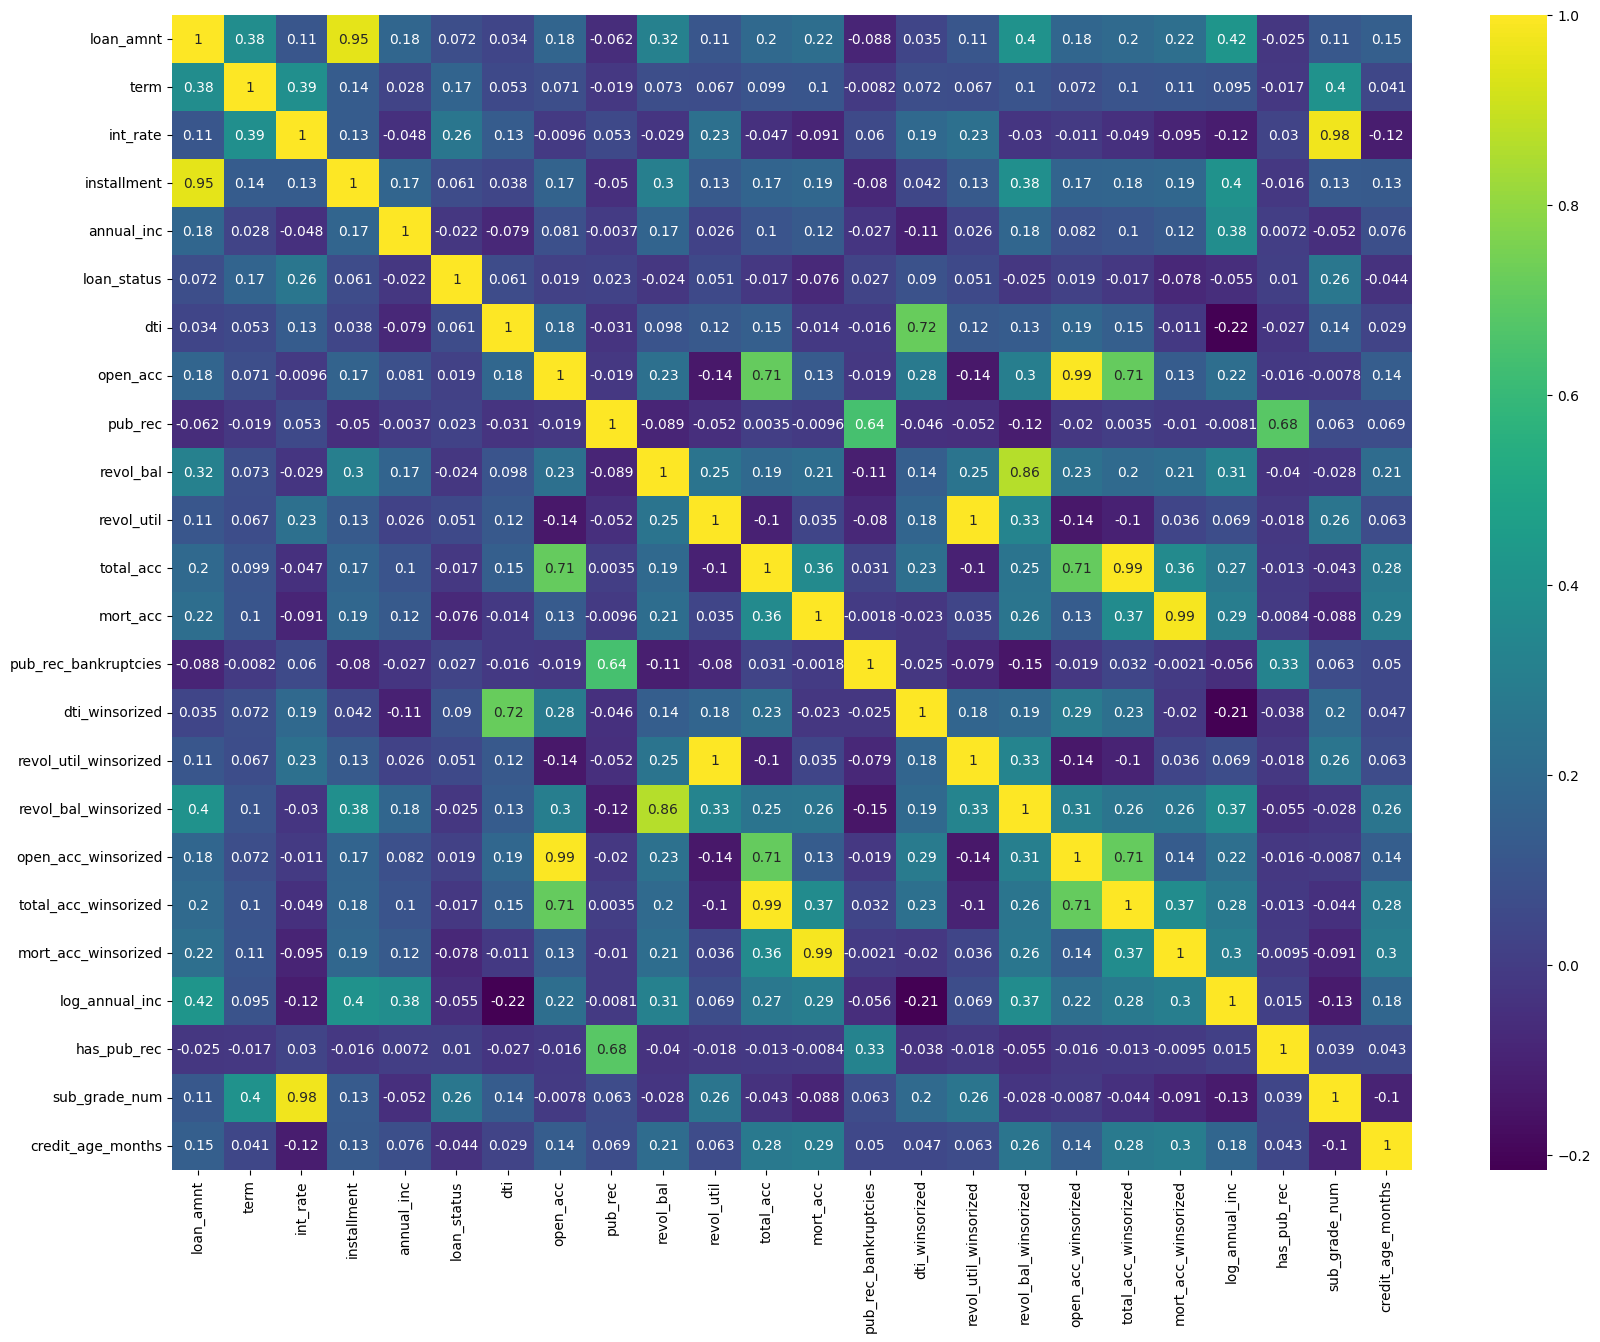

In [11]:
plt.figure(figsize=(20, 15))
sns.heatmap(df_eda.corr(numeric_only=True),annot=True, cmap='viridis')

In [ ]:
# drop unused columns

cols_to_prune = [
    'initial_list_status', 
    'application_type',
    'emp_title', 
    'emp_length', 
    'title', 
    'zip_code', 
    'issue_d',
    'earliest_cr_line',
    'grade',
    'annual_inc',
    'dti',
    'revol_bal',
    'revol_util',
    'open_acc',
    'total_acc',
    'total_acc_winsorized',
    'mort_acc',
    'interest',
    'pub_rec',
    'pub_rec_bankruptcies',
    'int_rate',
    'sub_grade',
    'installment'
]

# Execute the drop
df_eda.drop(columns=[c for c in cols_to_prune if c in df_eda.columns], inplace=True)

print(f"Pruning complete. Current columns: \n{df_eda.columns}")

Pruning complete. Current columns: 
Index(['loan_amnt', 'term', 'home_ownership', 'verification_status',
       'loan_status', 'purpose', 'addr_state', 'dti_winsorized',
       'revol_util_winsorized', 'revol_bal_winsorized', 'open_acc_winsorized',
       'mort_acc_winsorized', 'log_annual_inc', 'has_pub_rec', 'sub_grade_num',
       'credit_age_months'],
      dtype='object')


<Axes: >

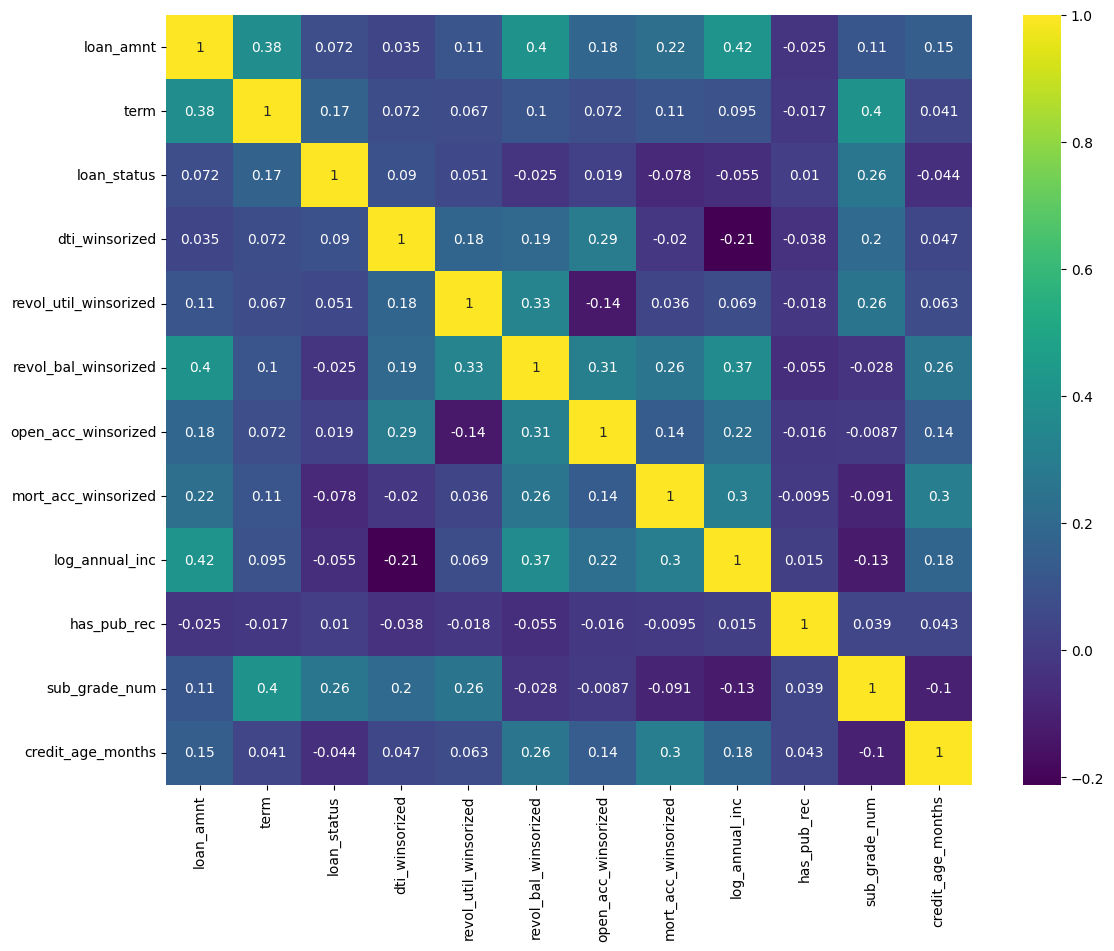

In [15]:
plt.figure(figsize=(13, 10))
sns.heatmap(df_eda.corr(numeric_only=True),annot=True, cmap='viridis')

In [12]:
# Saving the df to csv

df_eda.to_csv("preprocessed.csv", index=False)